# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [7]:
#Type your code here
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Mengatur gaya visualisasi
sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')
print("Library berhasil di-import!")

Library berhasil di-import!


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
#Type your code here
df = pd.read_csv(
    "/content/drive/MyDrive/Stupen/adult.csv"
)

df.head()
print(df.shape)
df.info()

(32561, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

Statistik Deskriptif Fitur Numerik:


,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


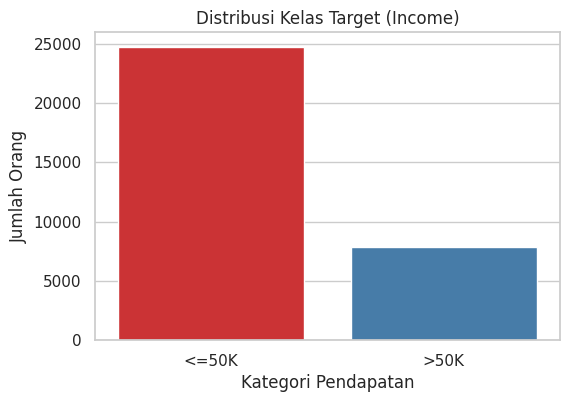

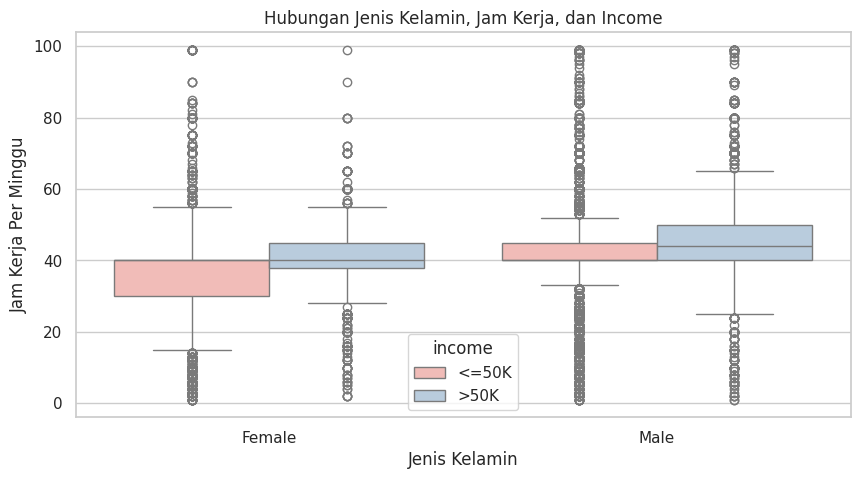

Pengecekan karakter '?' (Missing Value Tersembunyi):
- Kolom 'workclass' mengandung tanda '?' sebanyak: 1836 data
- Kolom 'occupation' mengandung tanda '?' sebanyak: 1843 data
- Kolom 'native.country' mengandung tanda '?' sebanyak: 583 data


In [5]:
# 1. Statistik deskriptif untuk fitur numerik
print("Statistik Deskriptif Fitur Numerik:")
display(df.describe())

# 2. Distribusi Kelas Target (Income)
plt.figure(figsize=(6, 4))
sns.countplot(x='income', data=df, palette='Set1')
plt.title('Distribusi Kelas Target (Income)')
plt.xlabel('Kategori Pendapatan')
plt.ylabel('Jumlah Orang')
plt.show()

# 3. Distribusi Jam Kerja Per Minggu berdasarkan Gender dan Income
plt.figure(figsize=(10, 5))
sns.boxplot(x='sex', y='hours.per.week', hue='income', data=df, palette='Pastel1')
plt.title('Hubungan Jenis Kelamin, Jam Kerja, dan Income')
plt.xlabel('Jenis Kelamin')
plt.ylabel('Jam Kerja Per Minggu')
plt.show()

# 4. Mengecek missing value yang tersembunyi (pada dataset ini biasanya berupa karakter '?')
print("Pengecekan karakter '?' (Missing Value Tersembunyi):")
for col in df.columns:
    if df[col].dtype == 'object':
        count_q = (df[col] == '?').sum()
        if count_q > 0:
            print(f"- Kolom '{col}' mengandung tanda '?' sebanyak: {count_q} data")

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [8]:
# 1. Menghapus Duplikat
duplicate_count = df.duplicated().sum()
print(f"Jumlah baris duplikat yang ditemukan: {duplicate_count}")
if duplicate_count > 0:
    df.drop_duplicates(inplace=True)
    print("Data duplikat berhasil dihapus.")

# 2. Mengatasi missing value tersembunyi ('?') menjadi NaN agar bisa di-impute
df.replace('?', np.nan, inplace=True)

# 3. Memisahkan Fitur (X) dan Target (y)
X = df.drop(columns=['income'])
y = df['income']

# 4. Memisahkan kolom numerik dan kategorikal secara otomatis
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("\nFitur Kategorikal:", categorical_cols)
print("Fitur Numerik:", numerical_cols)

# 5. Membuat Pipeline Preprocessing
# Untuk data numerik: Impute dengan median + Standarisasi
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Untuk data kategorikal: Impute dengan modus + One-Hot Encoding
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Menggabungkan kedua transformasi
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

# 6. Split Dataset menjadi Train dan Test (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 7. Eksekusi Preprocessing pada Data
X_train_ready = preprocessor.fit_transform(X_train)
X_test_ready = preprocessor.transform(X_test)

print(f"\nPreprocessing Selesai!")
print(f"Ukuran data training setelah One-Hot Encoding: {X_train_ready.shape}")
print(f"Ukuran data testing setelah One-Hot Encoding: {X_test_ready.shape}")

Jumlah baris duplikat yang ditemukan: 0

Fitur Kategorikal: ['workclass', 'education', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'native.country']
Fitur Numerik: ['age', 'fnlwgt', 'education.num', 'capital.gain', 'capital.loss', 'hours.per.week']

Preprocessing Selesai!
Ukuran data training setelah One-Hot Encoding: (26029, 104)
Ukuran data testing setelah One-Hot Encoding: (6508, 104)


In [11]:
# 1. Mengambil nama kolom baru setelah One-Hot Encoding
encoded_cat_cols = preprocessor.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_cols)
all_features = numerical_cols + list(encoded_cat_cols)

# 2. Mengubah array hasil preprocessing menjadi DataFrame yang rapi
X_train_preprocessed_df = pd.DataFrame(X_train_ready, columns=all_features)
X_test_preprocessed_df = pd.DataFrame(X_test_ready, columns=all_features)

# 3. Menggabungkan kembali dengan kolom target (income)
y_train_reset = y_train.reset_index(drop=True)
y_test_reset = y_test.reset_index(drop=True)

train_final = pd.concat([X_train_preprocessed_df, y_train_reset], axis=1)
test_final = pd.concat([X_test_preprocessed_df, y_test_reset], axis=1)

# 4. Menggabungkan data train dan test menjadi satu dataset utuh yang sudah bersih
df_clean_total = pd.concat([train_final, test_final], ignore_index=True)

# 5. PROSES MENYIMPAN: Mengubah menjadi file CSV
df_clean_total.to_csv('/content/drive/MyDrive/Stupen/adult_preprocessing.csv', index=False)

print("Selesai! File 'census_income_bersih.csv' telah berhasil disimpan.")

Selesai! File 'census_income_bersih.csv' telah berhasil disimpan.
